# 05 — Korean Evaluation Set

Applies the six detection approaches from Notebook 04 to the Korean test set from Song et al. (2023), enabling direct comparison against their reported QuoteCSE results on identical data (SRQ2).

**Dataset:** 1,600 annotated articles (814 contextomized, 786 modified).  
**Key difference from English set:** no pre-matched body sentence — matching is performed here using the same model as Notebook 02 (`paraphrase-multilingual-mpnet-base-v2`).  
**Primary metric:** AUC. F1 at fixed τ=0.5 reported for reference.

## 0. Setup

In [8]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from dotenv import load_dotenv
load_dotenv()

THRESHOLD = 0.5

In [9]:
from sklearn.metrics import confusion_matrix

def evaluate(y_true, scores, threshold=THRESHOLD, name=''):
    """Compute AUC, F1, sensitivity, specificity, precision."""
    preds = (scores >= threshold).astype(int)
    auc   = roc_auc_score(y_true, scores)
    f1    = f1_score(y_true, preds, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f"{'=== ' + name + ' ===' if name else ''}")
    print(f"AUC: {auc:.3f}  |  F1: {f1:.3f}  |  Sens: {sensitivity:.3f}  |  Spec: {specificity:.3f}  |  Prec: {precision:.3f}")
    return preds, auc, f1, sensitivity, specificity, precision

---
## 1. Quote Matching

The Korean set provides `body_quotes` (extracted quoted spans) and the full `body` text, but no pre-matched sentence. We replicate the matching procedure from Notebook 02: the headline quote is matched against all body sentences using `paraphrase-multilingual-mpnet-base-v2`, and the best-matching sentence plus its neighbours form the context window.

In [10]:
df = pd.read_csv('data/korean_matched.csv')
df['label'] = df['label'].astype(int)
for col in ['prev_sentence', 'next_sentence', 'best_body_sentence']:
    df[col] = df[col].fillna('')

y_true = df['label'].values
print(f"Loaded: {len(df)} articles")
print(f"Contextomized: {y_true.sum()}  |  Modified: {(y_true==0).sum()}")
print(f"Mean similarity: {df['best_sim'].mean():.3f}")

Loaded: 1600 articles
Contextomized: 814  |  Modified: 786
Mean similarity: 0.558


In [11]:
def build_premise(row):
    """Concatenate context window: prev + best body sentence + next."""
    parts = [row['prev_sentence'], row['best_body_sentence'], row['next_sentence']]
    return ' '.join(p for p in parts if p).strip()

---
## 2. Approach 1 — Cosine Similarity Threshold (τ=0.5)

In [12]:
cosine_scores = 1 - df['best_sim'].values
cosine_preds, cosine_auc, cosine_f1, cosine_sens, cosine_spec, cosine_prec = evaluate(
    y_true, cosine_scores, name='Cosine'
)

=== Cosine ===
AUC: 0.596  |  F1: 0.492  |  Sens: 0.419  |  Spec: 0.707  |  Prec: 0.597


---
## 3. Approach 2 — NLI (mDeBERTa)

Run on Snellius if slow on CPU — save scores to `data/korean_nli_scores.csv` using the same pattern as Notebook 04.

In [13]:
nli_results = pd.read_csv('data/korean_nli_scores.csv')
nli_scores  = nli_results['score_nli'].values
nli_preds   = nli_results['pred_nli'].values
_, nli_auc, nli_f1, nli_sens, nli_spec, nli_prec = evaluate(y_true, nli_scores, name='NLI')

=== NLI ===
AUC: 0.560  |  F1: 0.249  |  Sens: 0.157  |  Spec: 0.892  |  Prec: 0.601


---
## 4. Approaches 3–6 — GPT-4o

Same prompts as Notebook 04. English prompts are used without translation — GPT-4o handles Korean input natively.

In [14]:
import openai
import json
import os
import time
import re

client = openai.OpenAI(api_key=os.environ['OPENAI_API_KEY'])

SYSTEM_DIRECT = """You are a journalism ethics expert specialising in quote accuracy.

Definitions:
- MODIFIED: The headline quote faithfully preserves the speaker's meaning.
- CONTEXTOMIZED: The headline quote distorts the speaker's intended meaning by removing context, altering emphasis, or combining fragments in a misleading way.

You will receive a headline quote and the body text where it originated.
Output ONLY valid JSON with exactly two fields:
- "label": "CONTEXTOMIZED" or "MODIFIED"
- "probability": float 0.0-1.0, your estimated probability that the quote is contextomized"""

SYSTEM_COT = """You are a journalism ethics expert specialising in quote accuracy.

Definitions:
- MODIFIED: The headline quote faithfully preserves the speaker's meaning.
- CONTEXTOMIZED: The headline quote distorts the speaker's intended meaning by removing context, altering emphasis, or combining fragments in a misleading way.

Reason step by step, then output ONLY valid JSON with exactly four fields:
- "step1": What is the speaker's intended meaning in the body context? (1 sentence)
- "step2": Does the headline quote preserve or distort that meaning? (1 sentence)
- "label": "CONTEXTOMIZED" or "MODIFIED"
- "probability": float 0.0-1.0, your estimated probability that the quote is contextomized"""

def parse_response(text):
    text = text.strip().replace('```json','').replace('```','')
    try:
        parsed = json.loads(text)
    except json.JSONDecodeError:
        label_match = re.search(r'"label"\s*:\s*"(CONTEXTOMIZED|MODIFIED)"', text)
        prob_match  = re.search(r'"probability"\s*:\s*([0-9.]+)', text)
        if label_match and prob_match:
            return label_match.group(1), float(prob_match.group(1))
        raise
    return parsed['label'], float(parsed['probability'])

def run_gpt(df, system_prompt, input_type='context', max_tokens=60):
    """Run GPT classification. input_type: 'context' or 'full'."""
    labels, scores = [], []
    for i, (_, row) in enumerate(df.iterrows()):
        try:
            if input_type == 'context':
                body_text = build_premise(row)
                field = 'BODY CONTEXT'
            else:
                body_text = str(row['body'])[:6000]
                field = 'FULL ARTICLE'
            user_msg  = f'HEADLINE QUOTE: "{row["headline_quote"]}"\n{field}: "{body_text}"'
            response  = client.chat.completions.create(
                model='gpt-4o',
                messages=[
                    {'role': 'system', 'content': system_prompt},
                    {'role': 'user',   'content': user_msg}
                ],
                temperature=0,
                max_tokens=max_tokens
            )
            label, prob = parse_response(response.choices[0].message.content)
            labels.append(1 if label == 'CONTEXTOMIZED' else 0)
            scores.append(prob)
        except Exception as e:
            print(f"Row {i} failed: {e}")
            labels.append(0)
            scores.append(0.5)
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{len(df)} done")
        time.sleep(0.3)
    return np.array(labels), np.array(scores)

In [15]:
# Pilot on 5 rows before committing to 1600 calls
print("Pilot — GPT-4o direct, context window:")
for _, row in df.head(5).iterrows():
    body_text = build_premise(row)
    user_msg  = f'HEADLINE QUOTE: "{row["headline_quote"]}"\nBODY CONTEXT: "{body_text}"'
    response  = client.chat.completions.create(
        model='gpt-4o',
        messages=[
            {'role': 'system', 'content': SYSTEM_DIRECT},
            {'role': 'user',   'content': user_msg}
        ],
        temperature=0, max_tokens=60
    )
    label, prob = parse_response(response.choices[0].message.content)
    print(f"  gt={row['label']}  pred={label}  prob={prob:.2f}  |  {str(row['headline_quote'])[:60]}")
    time.sleep(0.3)

Pilot — GPT-4o direct, context window:
  gt=1  pred=MODIFIED  prob=0.20  |  ['한화그룹 비선조직이 비자금 조성 주도']
  gt=1  pred=MODIFIED  prob=0.10  |  ['한국, 올해 국민소득 2만불 재돌파']
  gt=1  pred=CONTEXTOMIZED  prob=0.90  |  ['새해 경기회복 빨라진다']
  gt=0  pred=MODIFIED  prob=0.20  |  ['반짝 늘던 매수문의 다시 잠잠']
  gt=1  pred=CONTEXTOMIZED  prob=0.90  |  ['올해 몸 조심해야 할 세력은...']


In [16]:
# ~1600 calls, ~10 mins
gpt_labels, gpt_scores = run_gpt(df, SYSTEM_DIRECT, input_type='context', max_tokens=60)
gpt_preds, gpt_auc, gpt_f1, gpt_sens, gpt_spec, gpt_prec = evaluate(y_true, gpt_scores, name='GPT-4o direct, context')
pd.DataFrame({'score': gpt_scores, 'pred': gpt_labels, 'label': y_true}).to_csv('data/korean_gpt_direct_ctx.csv', index=False)

  100/1600 done
  200/1600 done
  300/1600 done
  400/1600 done
  500/1600 done
  600/1600 done
  700/1600 done
  800/1600 done
  900/1600 done
  1000/1600 done
  1100/1600 done
  1200/1600 done
  1300/1600 done
  1400/1600 done
  1500/1600 done
  1600/1600 done
=== GPT-4o direct, context ===
AUC: 0.577  |  F1: 0.662  |  Sens: 0.826  |  Spec: 0.309  |  Prec: 0.553


In [17]:
cot_labels, cot_scores = run_gpt(df, SYSTEM_COT, input_type='context', max_tokens=200)
cot_preds, cot_auc, cot_f1, cot_sens, cot_spec, cot_prec = evaluate(y_true, cot_scores, name='GPT-4o CoT, context')
pd.DataFrame({'score': cot_scores, 'pred': cot_labels, 'label': y_true}).to_csv('data/korean_gpt_cot_ctx.csv', index=False)

Row 33 failed: Expecting value: line 1 column 1 (char 0)
  100/1600 done
  200/1600 done
  300/1600 done
Row 379 failed: Expecting value: line 1 column 1 (char 0)
Row 396 failed: Expecting value: line 1 column 1 (char 0)
  400/1600 done
  500/1600 done
Row 566 failed: Expecting value: line 1 column 1 (char 0)
  600/1600 done
  700/1600 done
  800/1600 done
  900/1600 done
  1000/1600 done
  1100/1600 done
  1200/1600 done
  1300/1600 done
  1400/1600 done
Row 1448 failed: Expecting value: line 1 column 1 (char 0)
  1500/1600 done
  1600/1600 done
=== GPT-4o CoT, context ===
AUC: 0.548  |  F1: 0.542  |  Sens: 0.537  |  Spec: 0.541  |  Prec: 0.548


In [18]:
# gpt_full_labels, gpt_full_scores = run_gpt(df, SYSTEM_DIRECT, input_type='full', max_tokens=60)
# gpt_full_preds, gpt_full_auc, gpt_full_f1, gpt_full_sens, gpt_full_spec, gpt_full_prec = evaluate(y_true, gpt_full_scores, name='GPT-4o direct, full')
# pd.DataFrame({'score': gpt_full_scores, 'pred': gpt_full_labels, 'label': y_true}).to_csv('data/korean_gpt_direct_full.csv', index=False)

In [19]:
# cot_full_labels, cot_full_scores = run_gpt(df, SYSTEM_COT, input_type='full', max_tokens=200)
# cot_full_preds, cot_full_auc, cot_full_f1, cot_full_sens, cot_full_spec, cot_full_prec = evaluate(y_true, cot_full_scores, name='GPT-4o CoT, full')
# pd.DataFrame({'score': cot_full_scores, 'pred': cot_full_labels, 'label': y_true}).to_csv('data/korean_gpt_cot_full.csv', index=False)

---
## 5. Results Summary

Comparison against Song et al. (2023) reported results on this identical test set.

In [20]:
results = pd.DataFrame([
    {'Method': 'BERT (Song et al.)',           'AUC': 0.662, 'F1': 0.665, 'Sens.': '--', 'Spec.': '--', 'Prec.': '--', 'Setting': 'supervised'},
    {'Method': 'BERT fine-tune (Song et al.)', 'AUC': 0.749, 'F1': 0.754, 'Sens.': '--', 'Spec.': '--', 'Prec.': '--', 'Setting': 'supervised'},
    {'Method': 'QuoteCSE (Song et al.)',       'AUC': 0.768, 'F1': 0.770, 'Sens.': '--', 'Spec.': '--', 'Prec.': '--', 'Setting': 'supervised'},
    {'Method': 'Cosine τ=0.5',                 'AUC': round(cosine_auc,3), 'F1': round(cosine_f1,3), 'Sens.': round(cosine_sens,3), 'Spec.': round(cosine_spec,3), 'Prec.': round(cosine_prec,3), 'Setting': 'zero-shot'},
    {'Method': 'mDeBERTa NLI',                 'AUC': round(nli_auc,3),    'F1': round(nli_f1,3),    'Sens.': round(nli_sens,3),    'Spec.': round(nli_spec,3),    'Prec.': round(nli_prec,3),    'Setting': 'zero-shot'},
    {'Method': 'GPT-4o direct (ctx)',           'AUC': round(gpt_auc,3),    'F1': round(gpt_f1,3),    'Sens.': round(gpt_sens,3),    'Spec.': round(gpt_spec,3),    'Prec.': round(gpt_prec,3),    'Setting': 'zero-shot'},
    {'Method': 'GPT-4o CoT (ctx)',              'AUC': round(cot_auc,3),    'F1': round(cot_f1,3),    'Sens.': round(cot_sens,3),    'Spec.': round(cot_spec,3),    'Prec.': round(cot_prec,3),    'Setting': 'zero-shot'},
    # {'Method': 'GPT-4o direct (full)',          'AUC': round(gpt_full_auc,3), 'F1': round(gpt_full_f1,3), 'Sens.': round(gpt_full_sens,3), 'Spec.': round(gpt_full_spec,3), 'Prec.': round(gpt_full_prec,3), 'Setting': 'zero-shot'},
    # {'Method': 'GPT-4o CoT (full)',             'AUC': round(cot_full_auc,3), 'F1': round(cot_full_f1,3), 'Sens.': round(cot_full_sens,3), 'Spec.': round(cot_full_spec,3), 'Prec.': round(cot_full_prec,3), 'Setting': 'zero-shot'},
])

print(results.to_string(index=False))

                      Method   AUC    F1  Sens.  Spec.  Prec.    Setting
          BERT (Song et al.) 0.662 0.665     --     --     -- supervised
BERT fine-tune (Song et al.) 0.749 0.754     --     --     -- supervised
      QuoteCSE (Song et al.) 0.768 0.770     --     --     -- supervised
                Cosine τ=0.5 0.596 0.492  0.419  0.707  0.597  zero-shot
                mDeBERTa NLI 0.560 0.249  0.157  0.892  0.601  zero-shot
         GPT-4o direct (ctx) 0.577 0.662  0.826  0.309  0.553  zero-shot
            GPT-4o CoT (ctx) 0.548 0.542  0.537  0.541  0.548  zero-shot


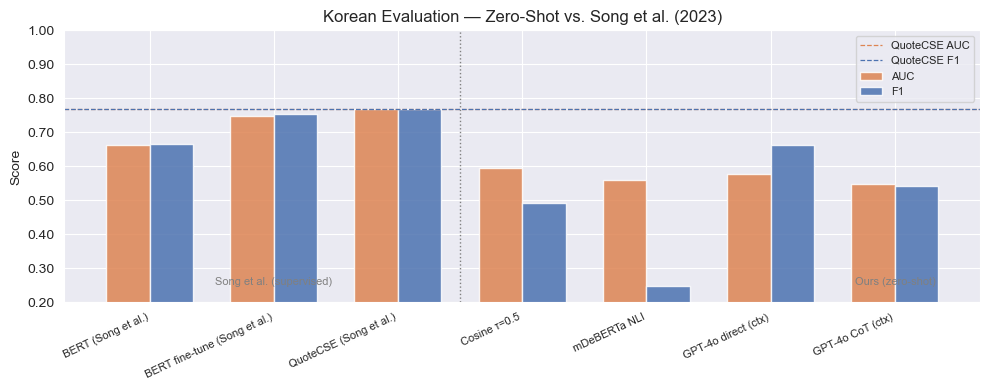

In [21]:
fig, ax = plt.subplots(figsize=(10, 4))
x, w = np.arange(len(results)), 0.35

ax.bar(x - w/2, pd.to_numeric(results['AUC'], errors='coerce'), w, label='AUC', color='#DD8452', alpha=0.85)
ax.bar(x + w/2, pd.to_numeric(results['F1'],  errors='coerce'), w, label='F1',  color='#4C72B0', alpha=0.85)

ax.axhline(0.768, color='#DD8452', linestyle='--', linewidth=0.9, label='QuoteCSE AUC')
ax.axhline(0.770, color='#4C72B0', linestyle='--', linewidth=0.9, label='QuoteCSE F1')
ax.axvline(2.5,   color='grey',    linestyle=':',  linewidth=1)
ax.text(1.0, 0.25, 'Song et al. (supervised)', ha='center', fontsize=8, color='grey')
ax.text(6.0, 0.25, 'Ours (zero-shot)',          ha='center', fontsize=8, color='grey')

ax.set_xticks(x)
ax.set_xticklabels(results['Method'], rotation=25, ha='right', fontsize=8)
ax.set_ylim(0.2, 1.0)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.set_ylabel('Score')
ax.set_title('Korean Evaluation — Zero-Shot vs. Song et al. (2023)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('data/korean_results_comparison.png', dpi=150)
plt.show()

---
## 6. Save All Predictions

In [22]:
df['score_cosine']   = cosine_scores
df['pred_cosine']    = cosine_preds
df['score_nli']      = nli_scores
df['pred_nli']       = nli_preds
df['score_gpt']      = gpt_scores
df['pred_gpt']       = gpt_preds
df['score_cot']      = cot_scores
df['pred_cot']       = cot_preds
# df['score_gpt_full'] = gpt_full_scores
# df['pred_gpt_full']  = gpt_full_preds
# df['score_cot_full'] = cot_full_scores
# df['pred_cot_full']  = cot_full_preds

df.to_csv('data/korean_predictions.csv', index=False)
print("Saved: data/korean_predictions.csv")
print()
print(results.to_string(index=False))

Saved: data/korean_predictions.csv

                      Method   AUC    F1  Sens.  Spec.  Prec.    Setting
          BERT (Song et al.) 0.662 0.665     --     --     -- supervised
BERT fine-tune (Song et al.) 0.749 0.754     --     --     -- supervised
      QuoteCSE (Song et al.) 0.768 0.770     --     --     -- supervised
                Cosine τ=0.5 0.596 0.492  0.419  0.707  0.597  zero-shot
                mDeBERTa NLI 0.560 0.249  0.157  0.892  0.601  zero-shot
         GPT-4o direct (ctx) 0.577 0.662  0.826  0.309  0.553  zero-shot
            GPT-4o CoT (ctx) 0.548 0.542  0.537  0.541  0.548  zero-shot
